In [6]:
# end_to_end_google_reviews_timeseries.py

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. CONFIG
# =========================
FILE_PATH = "y_amazon-google-large.csv"
TARGET_COL = "y"
DATE_COL = "ds"
ID_COL = "unique_id"
MODEL_PATH = "google_reviews_forecast_model.pkl"
FEATURE_PATH = "google_reviews_feature_columns.pkl"




In [7]:
# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv(FILE_PATH)

# Remove unwanted unnamed/index-like columns if present
drop_cols = [col for col in df.columns if "Unnamed" in col or col.strip().lower() == "column 1"]
df = df.drop(columns=drop_cols, errors="ignore")

print("Initial shape:", df.shape)
print("Columns:", df.columns.tolist())

Initial shape: (3055000, 3)
Columns: ['ds', 'y', 'unique_id']


In [8]:
# =========================
# 3. BASIC CLEANING
# =========================
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL, TARGET_COL])

# sort by series and time
if ID_COL in df.columns:
    df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)
else:
    df = df.sort_values(DATE_COL).reset_index(drop=True)

# numeric target
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df = df.dropna(subset=[TARGET_COL])

In [9]:
# =========================
# 4. FEATURE ENGINEERING
# =========================
def create_time_features(data):
    data = data.copy()

    data["hour"] = data[DATE_COL].dt.hour
    data["day"] = data[DATE_COL].dt.day
    data["dayofweek"] = data[DATE_COL].dt.dayofweek
    data["dayofyear"] = data[DATE_COL].dt.dayofyear
    data["weekofyear"] = data[DATE_COL].dt.isocalendar().week.astype(int)
    data["month"] = data[DATE_COL].dt.month
    data["quarter"] = data[DATE_COL].dt.quarter
    data["is_weekend"] = data["dayofweek"].isin([5, 6]).astype(int)

    # cyclical encoding
    data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)
    data["dow_sin"] = np.sin(2 * np.pi * data["dayofweek"] / 7)
    data["dow_cos"] = np.cos(2 * np.pi * data["dayofweek"] / 7)
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

    return data

def create_lag_features(data, target_col="y", group_col=None):
    data = data.copy()

    lag_list = [1, 2, 3, 6, 12, 24, 48, 72]
    roll_windows = [3, 6, 12, 24]

    if group_col and group_col in data.columns:
        grouped = data.groupby(group_col)

        for lag in lag_list:
            data[f"lag_{lag}"] = grouped[target_col].shift(lag)

        for window in roll_windows:
            data[f"rolling_mean_{window}"] = grouped[target_col].shift(1).rolling(window).mean().reset_index(level=0, drop=True)
            data[f"rolling_std_{window}"] = grouped[target_col].shift(1).rolling(window).std().reset_index(level=0, drop=True)
            data[f"rolling_min_{window}"] = grouped[target_col].shift(1).rolling(window).min().reset_index(level=0, drop=True)
            data[f"rolling_max_{window}"] = grouped[target_col].shift(1).rolling(window).max().reset_index(level=0, drop=True)
    else:
        for lag in lag_list:
            data[f"lag_{lag}"] = data[target_col].shift(lag)

        for window in roll_windows:
            data[f"rolling_mean_{window}"] = data[target_col].shift(1).rolling(window).mean()
            data[f"rolling_std_{window}"] = data[target_col].shift(1).rolling(window).std()
            data[f"rolling_min_{window}"] = data[target_col].shift(1).rolling(window).min()
            data[f"rolling_max_{window}"] = data[target_col].shift(1).rolling(window).max()

    return data

df = create_time_features(df)
df = create_lag_features(df, target_col=TARGET_COL, group_col=ID_COL if ID_COL in df.columns else None)

# Drop rows created with NaNs because of lag/rolling features
df = df.dropna().reset_index(drop=True)

print("Shape after feature engineering:", df.shape)

Shape after feature engineering: (3038080, 41)


In [10]:
# =========================
# 5. TRAIN-TEST SPLIT (TIME BASED)
# =========================
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

drop_feature_cols = [TARGET_COL, DATE_COL]
feature_cols = [col for col in df.columns if col not in drop_feature_cols]

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL]

X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (2430464, 39) (2430464,)
Test shape: (607616, 39) (607616,)


In [11]:
# =========================
# 6. MODEL TRAINING
# =========================
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [12]:
# =========================
# 7. EVALUATION
# =========================
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-" * 40)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

results = pd.DataFrame({
    "ds": test_df[DATE_COL].values,
    "actual": y_test.values,
    "predicted": y_pred
})

print("\nSample predictions:")
print(results.head(10))

# =========================
# 8. FEATURE IMPORTANCE
# =========================
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 15 Important Features:")
print(feature_importance.head(15))



Model Performance
----------------------------------------
MAE  : 14.9901
RMSE : 29.5309
R2   : 0.9831

Sample predictions:
                   ds  actual   predicted
0 2020-01-04 08:00:00   204.0  212.321076
1 2020-01-04 09:00:00   149.0  150.554943
2 2020-01-04 10:00:00   175.0  175.542003
3 2020-01-04 11:00:00   196.0  239.663829
4 2020-01-04 12:00:00   282.0  304.231112
5 2020-01-04 13:00:00   493.0  448.090153
6 2020-01-04 14:00:00   612.0  579.705039
7 2020-01-04 15:00:00   614.0  689.749616
8 2020-01-04 16:00:00   654.0  667.443873
9 2020-01-04 17:00:00   666.0  767.841393

Top 15 Important Features:
            feature  importance
15            lag_1    0.961043
20           lag_24    0.018933
9          hour_sin    0.007641
10         hour_cos    0.003901
35  rolling_mean_24    0.000961
1              hour    0.000708
24    rolling_std_3    0.000588
36   rolling_std_24    0.000514
21           lag_48    0.000486
22           lag_72    0.000441
19           lag_12    0.000406
0

In [13]:
# =========================
# 8. FEATURE IMPORTANCE
# =========================
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 15 Important Features:")
print(feature_importance.head(15))



Top 15 Important Features:
            feature  importance
15            lag_1    0.961043
20           lag_24    0.018933
9          hour_sin    0.007641
10         hour_cos    0.003901
35  rolling_mean_24    0.000961
1              hour    0.000708
24    rolling_std_3    0.000588
36   rolling_std_24    0.000514
21           lag_48    0.000486
22           lag_72    0.000441
19           lag_12    0.000406
0         unique_id    0.000398
32   rolling_std_12    0.000339
25    rolling_min_3    0.000265
31  rolling_mean_12    0.000260


In [14]:
# =========================
# 9. SAVE MODEL
# =========================
joblib.dump(model, MODEL_PATH)
joblib.dump(feature_cols, FEATURE_PATH)

print(f"\nSaved model to: {MODEL_PATH}")
print(f"Saved feature list to: {FEATURE_PATH}")


Saved model to: google_reviews_forecast_model.pkl
Saved feature list to: google_reviews_feature_columns.pkl


In [15]:
# =========================
# 10. FUTURE PREDICTION FUNCTION
# =========================
def predict_on_new_data(new_df, trained_model, feature_columns):
    new_df = new_df.copy()
    new_df[DATE_COL] = pd.to_datetime(new_df[DATE_COL], errors="coerce")
    new_df = create_time_features(new_df)
    new_df = create_lag_features(new_df, target_col=TARGET_COL, group_col=ID_COL if ID_COL in new_df.columns else None)
    new_df = new_df.dropna().reset_index(drop=True)

    X_new = new_df[feature_columns]
    new_df["prediction"] = trained_model.predict(X_new)
    return new_df[[DATE_COL, "prediction"]]

print("\nPipeline completed successfully.")


Pipeline completed successfully.


In [18]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_PATH = "y_amazon-google-large.csv"
MODEL_PATH = "google_reviews_forecast_model.pkl"
FEATURES_PATH = "google_reviews_feature_columns.pkl"
OUTPUT_XLSX = "output/ml_model_report.xlsx"

DATE_COL = "ds"
TARGET_COL = "y"
ID_COL = "unique_id"

os.makedirs("output", exist_ok=True)

# check files first
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Data file not found: {DATA_PATH}")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

if not os.path.exists(FEATURES_PATH):
    raise FileNotFoundError(f"Features file not found: {FEATURES_PATH}")

# load data
df = pd.read_csv(DATA_PATH)

drop_cols = [c for c in df.columns if "Unnamed" in c or c.strip().lower() == "column 1"]
df = df.drop(columns=drop_cols, errors="ignore")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL, TARGET_COL])

if ID_COL in df.columns:
    df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)
else:
    df = df.sort_values(DATE_COL).reset_index(drop=True)

def create_time_features(data):
    data = data.copy()
    data["hour"] = data[DATE_COL].dt.hour
    data["day"] = data[DATE_COL].dt.day
    data["dayofweek"] = data[DATE_COL].dt.dayofweek
    data["dayofyear"] = data[DATE_COL].dt.dayofyear
    data["weekofyear"] = data[DATE_COL].dt.isocalendar().week.astype(int)
    data["month"] = data[DATE_COL].dt.month
    data["quarter"] = data[DATE_COL].dt.quarter
    data["is_weekend"] = data["dayofweek"].isin([5, 6]).astype(int)
    data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)
    data["dow_sin"] = np.sin(2 * np.pi * data["dayofweek"] / 7)
    data["dow_cos"] = np.cos(2 * np.pi * data["dayofweek"] / 7)
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)
    return data

def create_lag_features(data):
    data = data.copy()
    lag_list = [1, 2, 3, 6, 12, 24, 48, 72]
    roll_list = [3, 6, 12, 24]

    if ID_COL in data.columns:
        for lag in lag_list:
            data[f"lag_{lag}"] = data.groupby(ID_COL)[TARGET_COL].shift(lag)

        for w in roll_list:
            shifted = data.groupby(ID_COL)[TARGET_COL].shift(1)
            data[f"rolling_mean_{w}"] = shifted.groupby(data[ID_COL]).transform(lambda s: s.rolling(w).mean())
            data[f"rolling_std_{w}"] = shifted.groupby(data[ID_COL]).transform(lambda s: s.rolling(w).std())
            data[f"rolling_min_{w}"] = shifted.groupby(data[ID_COL]).transform(lambda s: s.rolling(w).min())
            data[f"rolling_max_{w}"] = shifted.groupby(data[ID_COL]).transform(lambda s: s.rolling(w).max())
    else:
        for lag in lag_list:
            data[f"lag_{lag}"] = data[TARGET_COL].shift(lag)

        shifted = data[TARGET_COL].shift(1)
        for w in roll_list:
            data[f"rolling_mean_{w}"] = shifted.rolling(w).mean()
            data[f"rolling_std_{w}"] = shifted.rolling(w).std()
            data[f"rolling_min_{w}"] = shifted.rolling(w).min()
            data[f"rolling_max_{w}"] = shifted.rolling(w).max()

    return data

df_feat = create_time_features(df)
df_feat = create_lag_features(df_feat)

# load model and feature list
model = joblib.load(MODEL_PATH)
feature_cols = joblib.load(FEATURES_PATH)

# add missing columns as NaN, then drop rows that still cannot be used
for col in feature_cols:
    if col not in df_feat.columns:
        df_feat[col] = np.nan

df_feat = df_feat.dropna(subset=feature_cols).reset_index(drop=True)

split_idx = int(len(df_feat) * 0.8)
test_df = df_feat.iloc[split_idx:].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET_COL].copy()
y_pred = model.predict(X_test)

eda_sheet = pd.DataFrame({
    "metric": [
        "rows", "columns", "start_date", "end_date",
        "target_mean", "target_std", "target_min", "target_max"
    ],
    "value": [
        len(df),
        df.shape[1],
        df[DATE_COL].min(),
        df[DATE_COL].max(),
        df[TARGET_COL].mean(),
        df[TARGET_COL].std(),
        df[TARGET_COL].min(),
        df[TARGET_COL].max()
    ]
})

actual_vs_pred = test_df[[DATE_COL]].copy()
if ID_COL in test_df.columns:
    actual_vs_pred[ID_COL] = test_df[ID_COL].values
actual_vs_pred["actual"] = y_test.values
actual_vs_pred["predicted"] = y_pred
actual_vs_pred["error"] = actual_vs_pred["actual"] - actual_vs_pred["predicted"]

metrics_sheet = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "value": [
        mean_absolute_error(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred)),
        r2_score(y_test, y_pred)
    ]
})

output_sheet = pd.DataFrame({
    "item": ["model_path", "features_path", "excel_path"],
    "value": [MODEL_PATH, FEATURES_PATH, OUTPUT_XLSX]
})

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    eda_sheet.to_excel(writer, sheet_name="EDA", index=False)
    metrics_sheet.to_excel(writer, sheet_name="Model_Metrics", index=False)
    actual_vs_pred.to_excel(writer, sheet_name="Actual_vs_Predicted", index=False)
    output_sheet.to_excel(writer, sheet_name="Output", index=False)

print("Excel written:", OUTPUT_XLSX)

Excel written: output/ml_model_report.xlsx


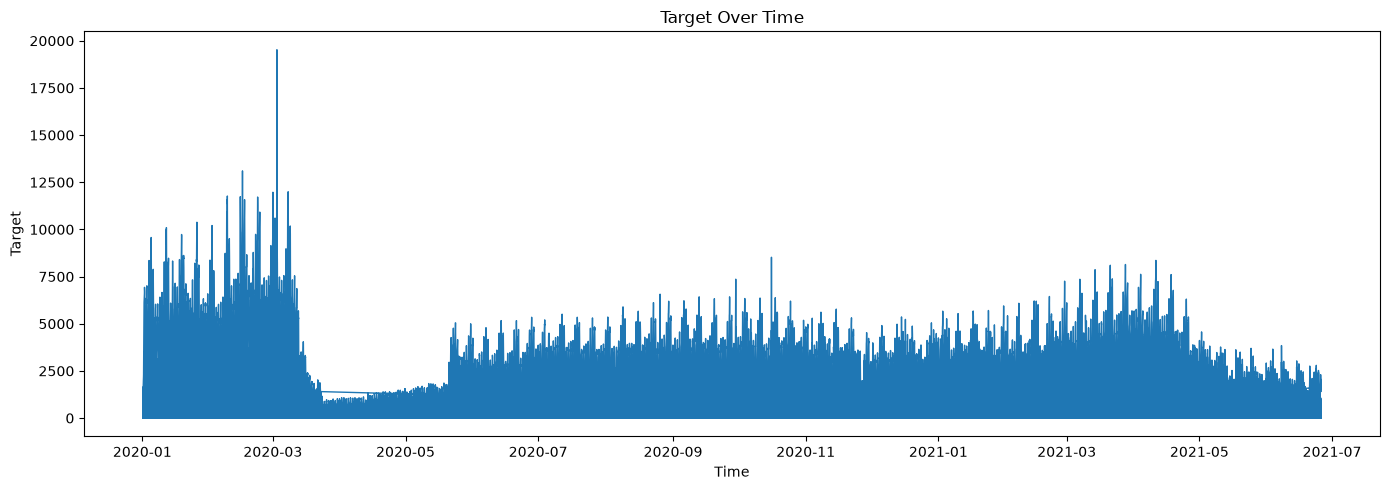

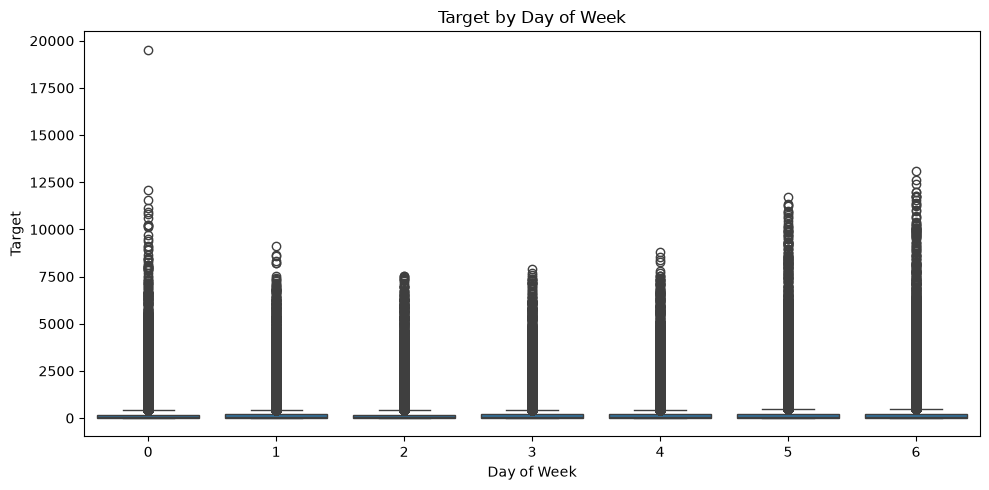

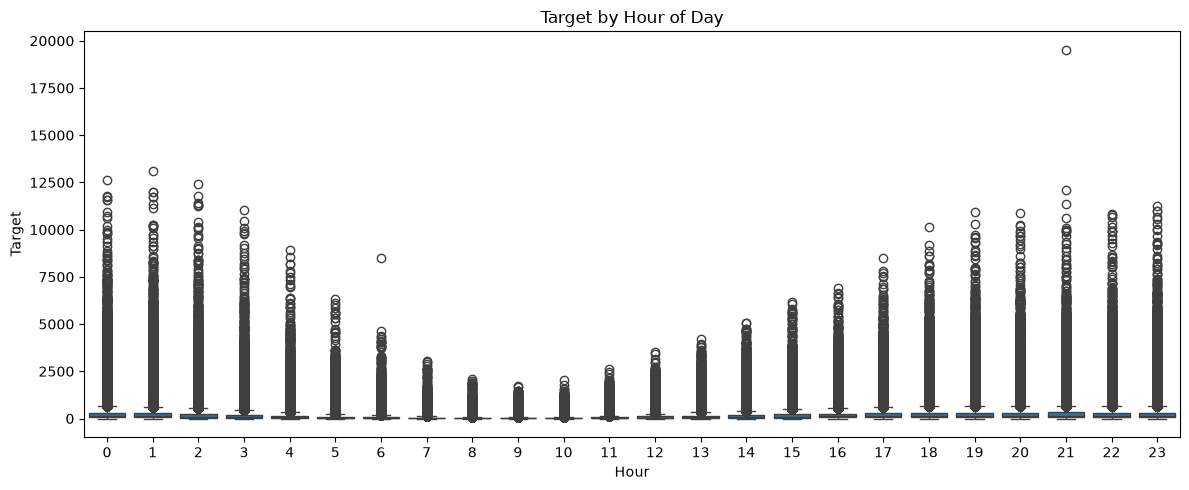

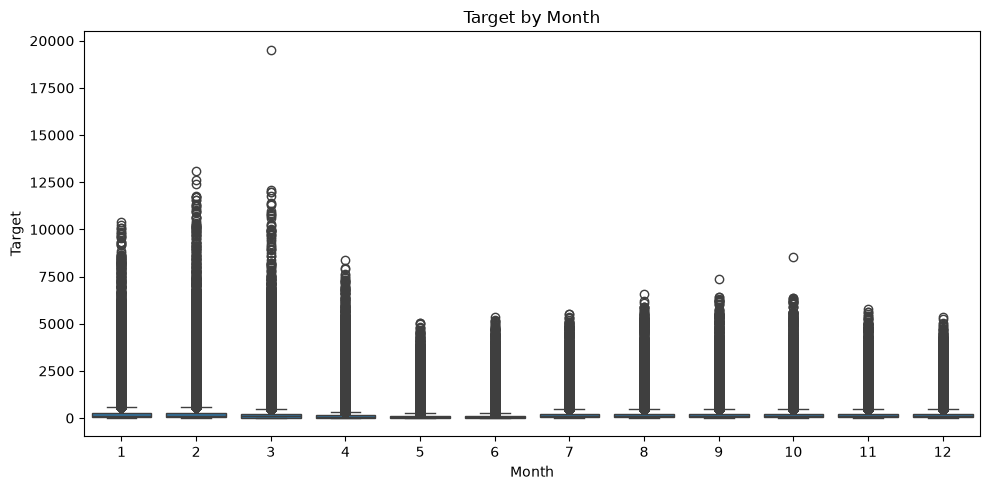

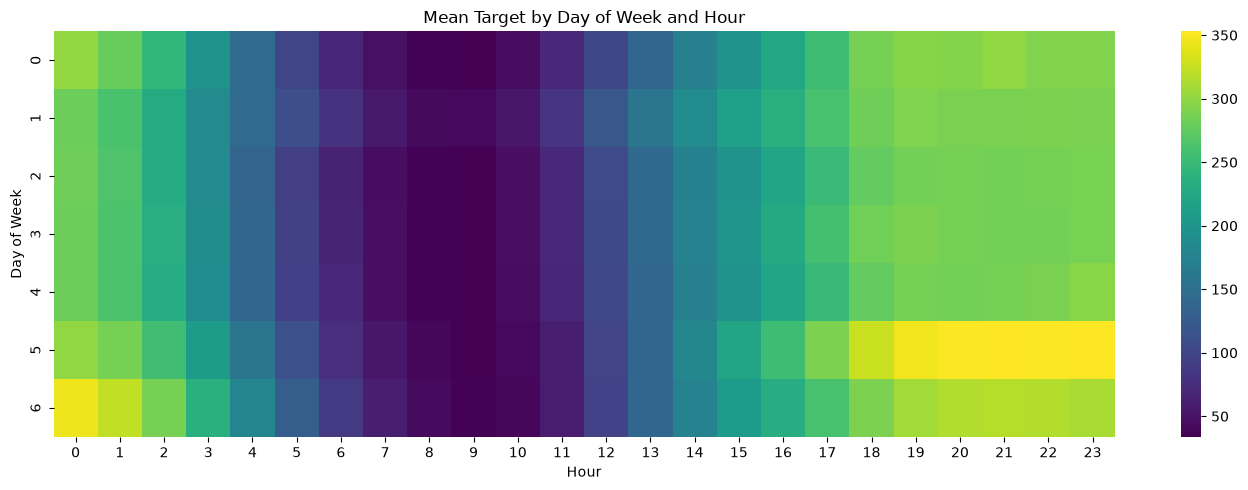

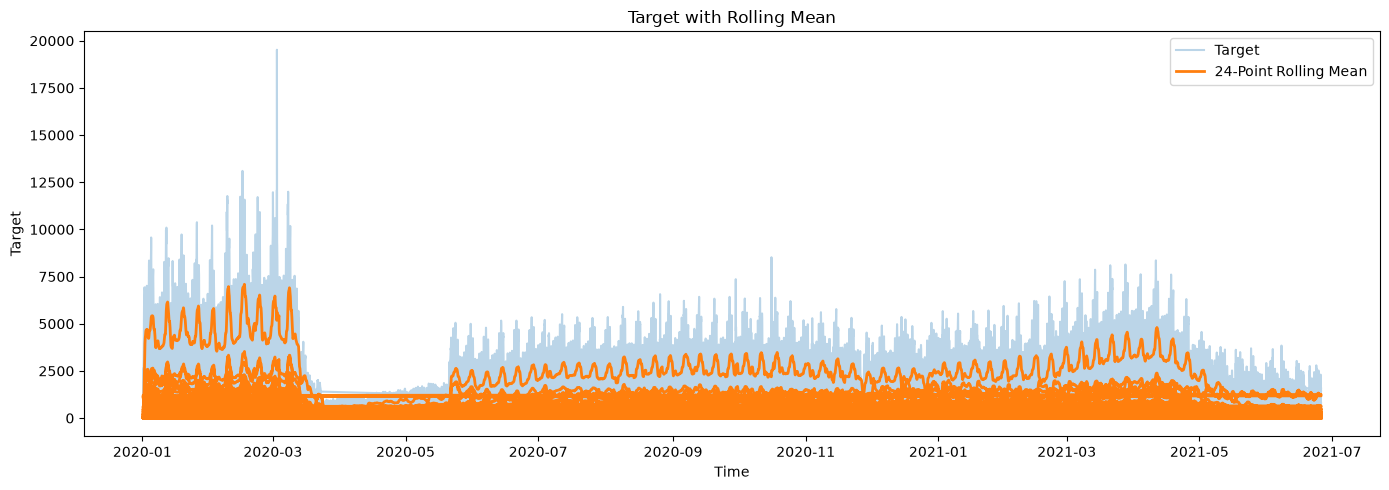

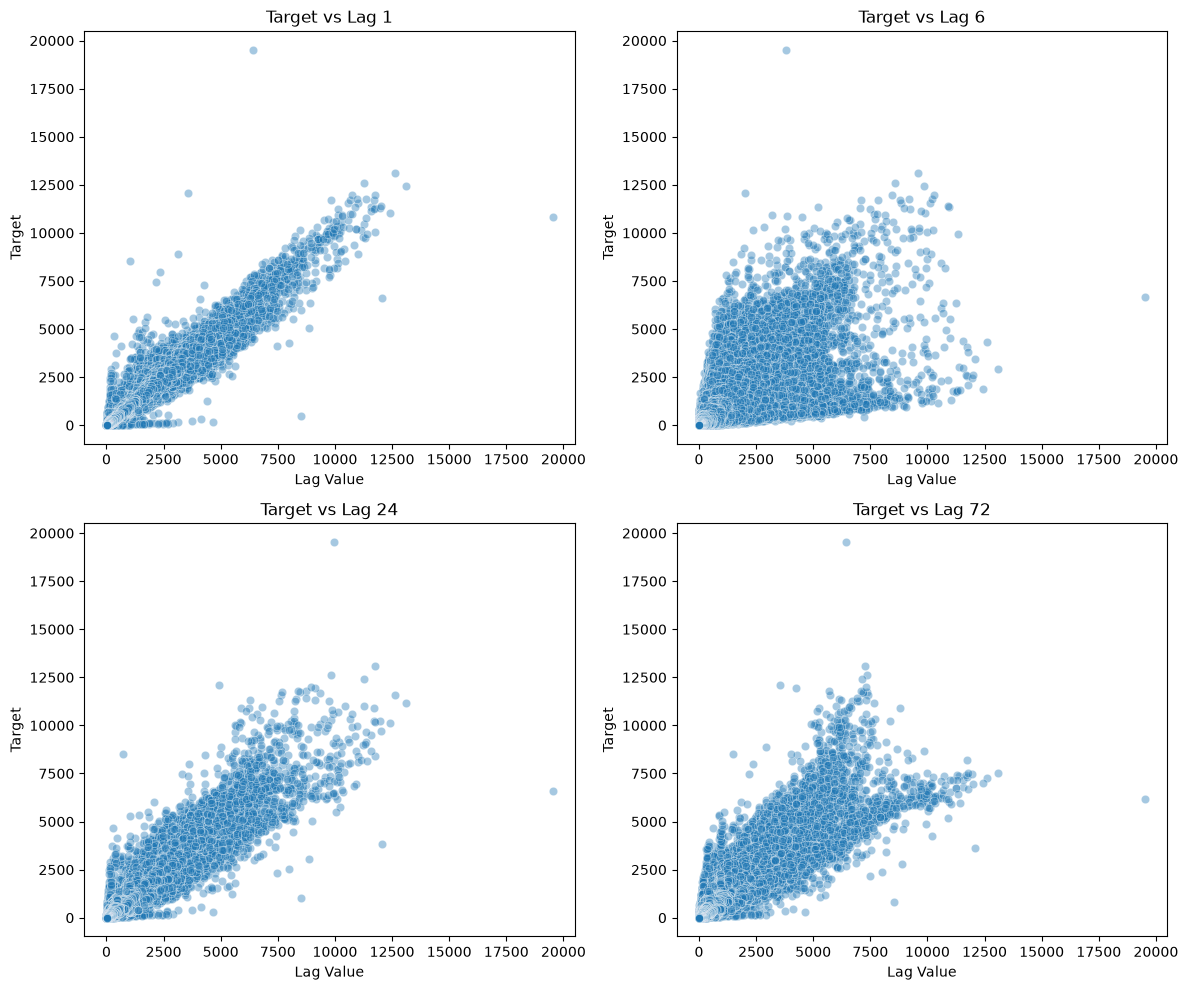

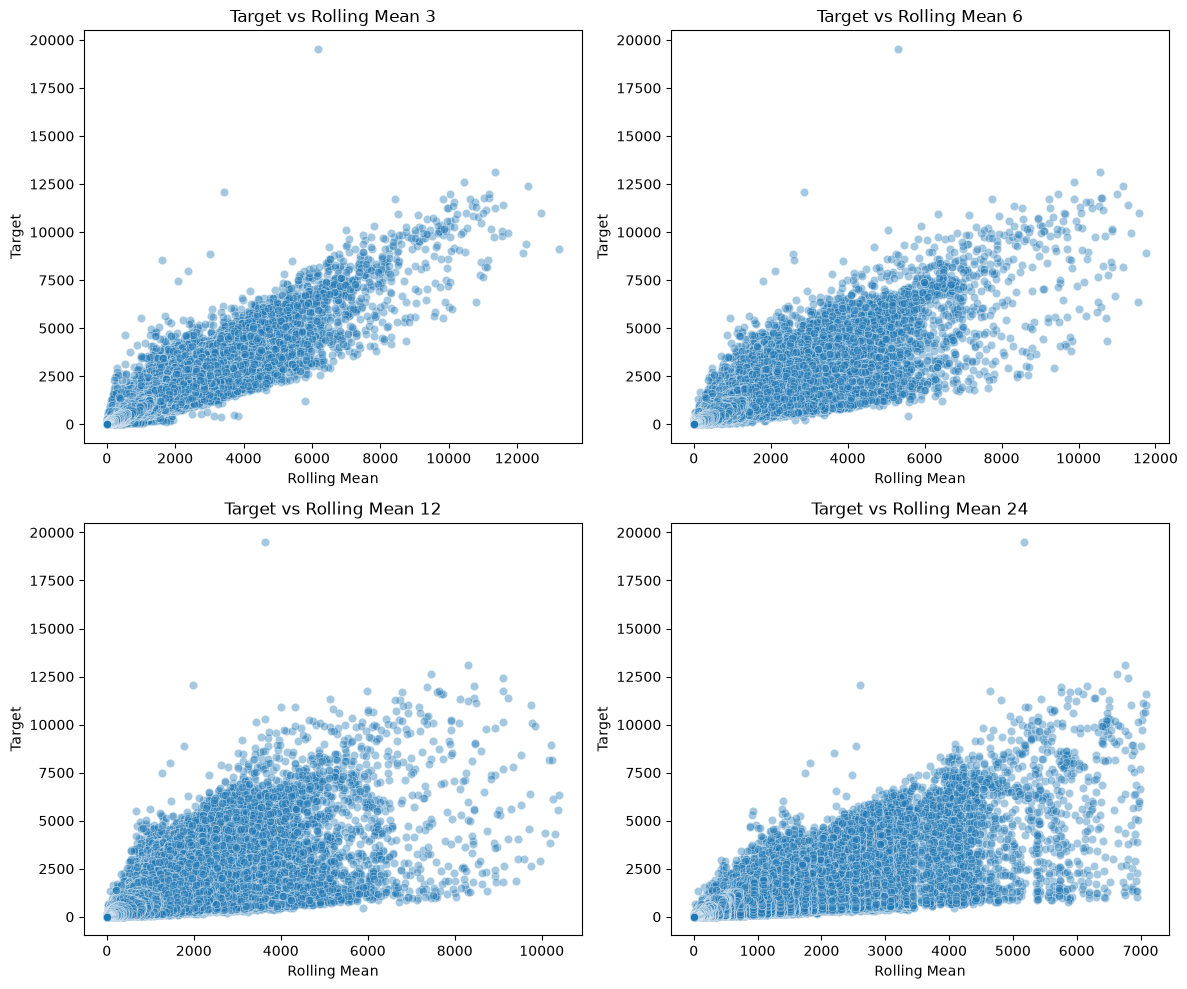

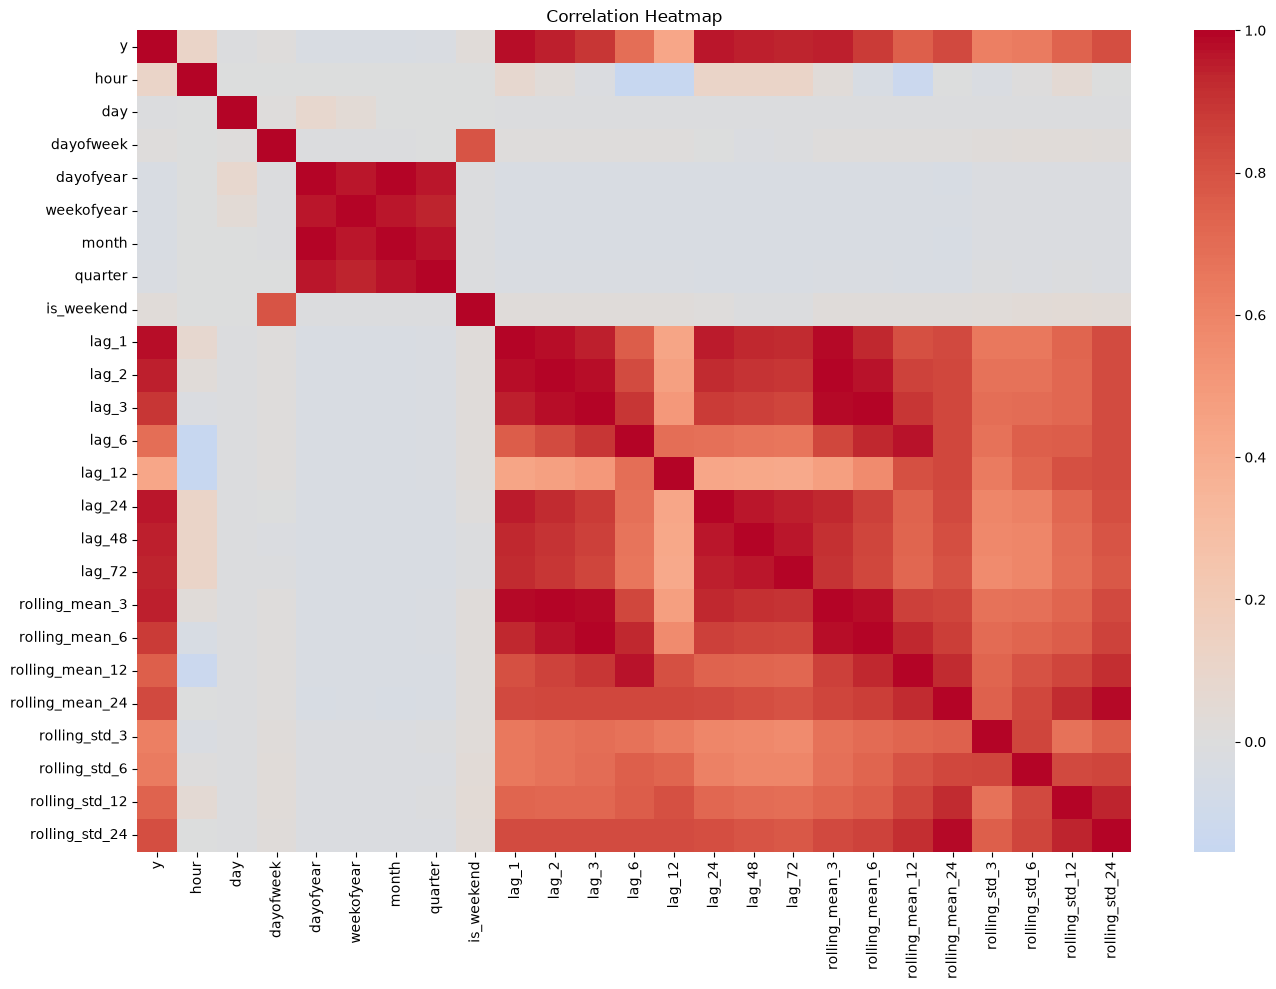

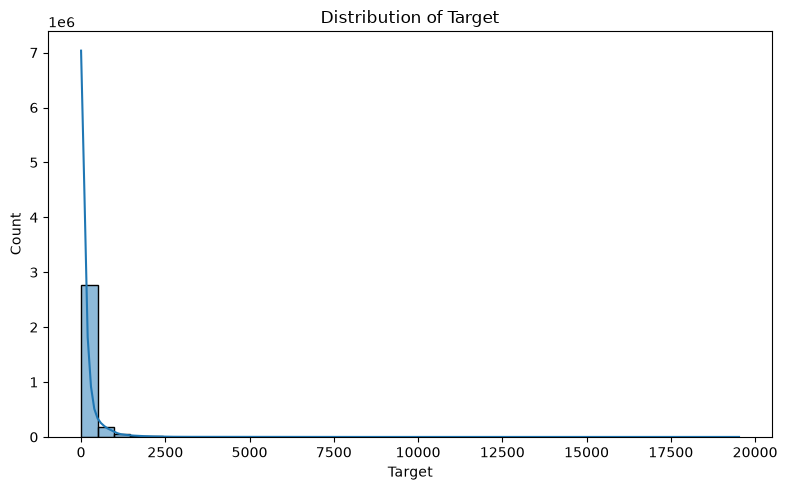

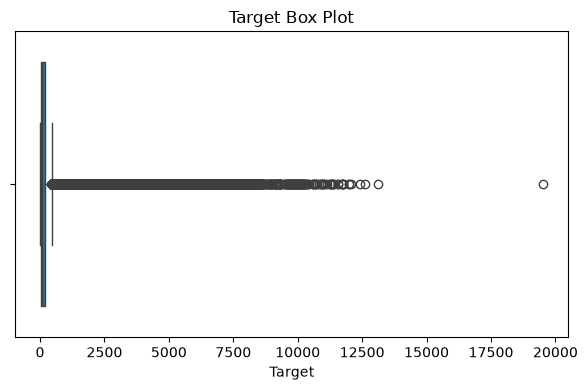

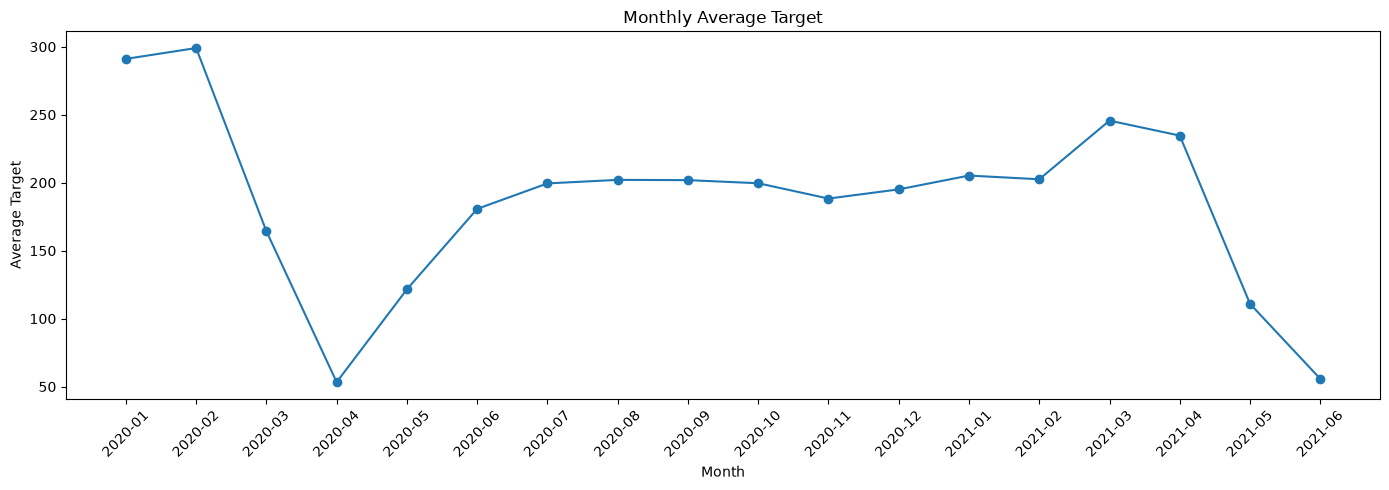

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA
# =========================
DATA_PATH = "y_amazon-google-large.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError("No dataset found.")

df = pd.read_csv(DATA_PATH)

drop_cols = [c for c in df.columns if "Unnamed" in c or c.strip().lower() == "column 1"]
df = df.drop(columns=drop_cols, errors="ignore")

df["ds"] = pd.to_datetime(df["ds"], errors="coerce")
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df = df.dropna(subset=["ds", "y"])

if "unique_id" in df.columns:
    df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)
else:
    df = df.sort_values("ds").reset_index(drop=True)

# =========================
# TIME FEATURES
# =========================
df["hour"] = df["ds"].dt.hour
df["day"] = df["ds"].dt.day
df["dayofweek"] = df["ds"].dt.dayofweek
df["dayofyear"] = df["ds"].dt.dayofyear
df["weekofyear"] = df["ds"].dt.isocalendar().week.astype(int)
df["month"] = df["ds"].dt.month
df["quarter"] = df["ds"].dt.quarter
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# =========================
# LAG / ROLLING FEATURES FOR PLOTS ONLY
# =========================
lag_list = [1, 2, 3, 6, 12, 24, 48, 72]
roll_list = [3, 6, 12, 24]

if "unique_id" in df.columns:
    for lag in lag_list:
        df[f"lag_{lag}"] = df.groupby("unique_id")["y"].shift(lag)
    for w in roll_list:
        shifted = df.groupby("unique_id")["y"].shift(1)
        df[f"rolling_mean_{w}"] = shifted.groupby(df["unique_id"]).transform(lambda s: s.rolling(w).mean())
        df[f"rolling_std_{w}"] = shifted.groupby(df["unique_id"]).transform(lambda s: s.rolling(w).std())
else:
    for lag in lag_list:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    shifted = df["y"].shift(1)
    for w in roll_list:
        df[f"rolling_mean_{w}"] = shifted.rolling(w).mean()
        df[f"rolling_std_{w}"] = shifted.rolling(w).std()

df_feat = df.dropna().reset_index(drop=True)

# =========================
# PLOT 1: TARGET OVER TIME
# =========================
plt.figure(figsize=(14, 5))
plt.plot(df["ds"], df["y"], linewidth=1)
plt.title("Target Over Time")
plt.xlabel("Time")
plt.ylabel("Target")
plt.tight_layout()
plt.show()

# =========================
# PLOT 2: TARGET BY DAY OF WEEK
# =========================
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_feat, x="dayofweek", y="y")
plt.title("Target by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Target")
plt.tight_layout()
plt.show()

# =========================
# PLOT 3: TARGET BY HOUR
# =========================
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_feat, x="hour", y="y")
plt.title("Target by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Target")
plt.tight_layout()
plt.show()

# =========================
# PLOT 4: TARGET BY MONTH
# =========================
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_feat, x="month", y="y")
plt.title("Target by Month")
plt.xlabel("Month")
plt.ylabel("Target")
plt.tight_layout()
plt.show()

# =========================
# PLOT 5: HEATMAP OF AVERAGE TARGET BY HOUR AND DAY
# =========================
pivot_heat = df.pivot_table(index="dayofweek", columns="hour", values="y", aggfunc="mean")
plt.figure(figsize=(14, 5))
sns.heatmap(pivot_heat, cmap="viridis")
plt.title("Mean Target by Day of Week and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

# =========================
# PLOT 6: ROLLING MEAN OF TARGET
# =========================
plt.figure(figsize=(14, 5))
plt.plot(df["ds"], df["y"], alpha=0.3, label="Target")
plt.plot(df["ds"], df["y"].rolling(24).mean(), linewidth=2, label="24-Point Rolling Mean")
plt.title("Target with Rolling Mean")
plt.xlabel("Time")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# PLOT 7: LAG PLOTS
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(x=df_feat["lag_1"], y=df_feat["y"], ax=axes[0, 0], alpha=0.4)
axes[0, 0].set_title("Target vs Lag 1")
sns.scatterplot(x=df_feat["lag_6"], y=df_feat["y"], ax=axes[0, 1], alpha=0.4)
axes[0, 1].set_title("Target vs Lag 6")
sns.scatterplot(x=df_feat["lag_24"], y=df_feat["y"], ax=axes[1, 0], alpha=0.4)
axes[1, 0].set_title("Target vs Lag 24")
sns.scatterplot(x=df_feat["lag_72"], y=df_feat["y"], ax=axes[1, 1], alpha=0.4)
axes[1, 1].set_title("Target vs Lag 72")
for ax in axes.ravel():
    ax.set_xlabel("Lag Value")
    ax.set_ylabel("Target")
plt.tight_layout()
plt.show()

# =========================
# PLOT 8: ROLLING FEATURE PLOTS
# =========================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(x=df_feat["rolling_mean_3"], y=df_feat["y"], ax=axes[0, 0], alpha=0.4)
axes[0, 0].set_title("Target vs Rolling Mean 3")
sns.scatterplot(x=df_feat["rolling_mean_6"], y=df_feat["y"], ax=axes[0, 1], alpha=0.4)
axes[0, 1].set_title("Target vs Rolling Mean 6")
sns.scatterplot(x=df_feat["rolling_mean_12"], y=df_feat["y"], ax=axes[1, 0], alpha=0.4)
axes[1, 0].set_title("Target vs Rolling Mean 12")
sns.scatterplot(x=df_feat["rolling_mean_24"], y=df_feat["y"], ax=axes[1, 1], alpha=0.4)
axes[1, 1].set_title("Target vs Rolling Mean 24")
for ax in axes.ravel():
    ax.set_xlabel("Rolling Mean")
    ax.set_ylabel("Target")
plt.tight_layout()
plt.show()

# =========================
# PLOT 9: CORRELATION HEATMAP
# =========================
num_cols = [
    "y", "hour", "day", "dayofweek", "dayofyear", "weekofyear",
    "month", "quarter", "is_weekend"
] + [f"lag_{i}" for i in lag_list] + [f"rolling_mean_{i}" for i in roll_list] + [f"rolling_std_{i}" for i in roll_list]

num_cols = [c for c in num_cols if c in df_feat.columns]

plt.figure(figsize=(14, 10))
sns.heatmap(df_feat[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# =========================
# PLOT 10: DISTRIBUTION OF TARGET
# =========================
plt.figure(figsize=(8, 5))
sns.histplot(df["y"], bins=40, kde=True)
plt.title("Distribution of Target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# =========================
# PLOT 11: BOX PLOT OF TARGET
# =========================
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["y"])
plt.title("Target Box Plot")
plt.xlabel("Target")
plt.tight_layout()
plt.show()

# =========================
# PLOT 12: MONTHLY TREND
# =========================
monthly = df.groupby(df["ds"].dt.to_period("M"))["y"].mean().reset_index()
monthly["ds"] = monthly["ds"].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly["ds"], monthly["y"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Average Target")
plt.xlabel("Month")
plt.ylabel("Average Target")
plt.tight_layout()
plt.show()